### ¿Cómo narices funciona la API?

In [1]:
import pandas as pd
import os
import json
from dotenv import load_dotenv

In [2]:
# Carga las variables del archivo .env en el entorno del sistema
# Si el archivo .env está en la misma carpeta que este notebook, basta con esto:
# Al usar '../.env', le decimos que salga de 'sandbox' y busque el archivo en la raíz
load_dotenv()
# Si tu .env está en una carpeta superior o una ruta específica, puedes indicarla:
# load_dotenv(dotenv_path="../.env")

# Recuperamos el token de forma segura
TOKEN = os.getenv("API_ESIOS")

# Verificación rápida (sin mostrar el token entero por seguridad)
if TOKEN:
    print(f"✅ Token cargado correctamente. Longitud: {len(TOKEN)} caracteres.")
else:
    print("❌ No se pudo encontrar la variable ESIOS_TOKEN. Revisa la ruta del archivo .env.")

✅ Token cargado correctamente. Longitud: 64 caracteres.


In [3]:
import datetime

from pyesios import ESIOS

In [4]:
end_ = datetime.datetime.today()
start_ = end_ - datetime.timedelta(days=30)

# The token is unique: You should ask for yours to:
#   Consultas Sios <consultasios@ree.es>

esios = ESIOS(TOKEN)

Getting the indicators...


In [5]:
# esios.save_indicators_table()

#    indicators_ = [600, 672, 673, 674, 675, 676, 677, 680, 681, 682, 683,
#   767, 1192, 1193, 1293]
indicators_ = list()
# indicators_.append(682)  # Precio de Regulación Secundaria subir
# indicators_.append(683)  # Precio de Regulación Secundaria bajar
indicators_.append(600)  # Precio mercado SPOT Diario
# indicators_.append(1293)  # Demanda real
indicators_.append(551)  # Eólica T.Real
# names = esios.get_names(indicators_)
df_list, names = esios.get_multiple_series(indicators_, start_, end_)

df_merged = esios.merge_series(
    df_list, names
)  # merge the DataFrames into a single one

df = df_merged[
    names
]  # get the actual series and neglect the rest of the info

df

Parsing Precio mercado SPOT Diario
Parsing Generación T.Real eólica
merging


,Precio mercado SPOT Diario,Generación T.Real eólica
datetime_utc,,
2026-05-27 18:15:00+00:00,111.95,4080.0
2026-05-27 18:30:00+00:00,129.71,4196.0
2026-05-27 18:45:00+00:00,135.84,4498.0
2026-05-27 19:00:00+00:00,138.02,4668.0
2026-05-27 19:15:00+00:00,145.71,4905.0
...,...,...
2026-06-26 17:00:00+00:00,70.10,5076.0
2026-06-26 17:15:00+00:00,79.55,5410.0
2026-06-26 17:30:00+00:00,85.00,5599.0


In [6]:
pd.read_pickle("indicators.pickle")


[{'indicadores de curvas de oferta': {'Curvas de ofertas Banda de regulación secundaria bajar': 601,
   'Curvas de ofertas Reserva de potencia adicional a subir': 629,
   'Curvas de ofertas Banda de regulación secundaria subir': 635,
   'Curvas de ofertas: energías de balance RR subir': 670,
   'Curvas de ofertas: energías de balance RR bajar': 671,
   'Curvas de ofertas Regulación Terciaria bajar': 678,
   'Curvas de ofertas Regulación Terciaria subir': 679,
   'Curvas de ofertas subasta explícita diaria FR-ES importación': 1089,
   'Curvas de ofertas subasta explícita diaria FR-ES exportación': 1090,
   'Curvas de ofertas subasta explícita intradiaria 1 FR-ES importación': 1091,
   'Curvas de ofertas subasta explícita intradiaria 1 FR-ES exportación': 1092,
   'Curvas de ofertas subasta explícita intradiaria 2 FR-ES importación': 1093,
   'Curvas de ofertas subasta explícita intradiaria 2 FR-ES exportación': 1094,
   'Curvas de ofertas subasta explícita mensual FR-ES importación': 10

In [7]:
indicators_ = list()
indicators_.append(1293) #Demanda consumo
indicators_.append(546) #Generación hidráulica
indicators_.append(551) #Generación solar
indicators_.append(553) #Generación tiempo real

df_list, names = esios.get_multiple_series(indicators_, start_, end_)

df_merged = esios.merge_series(
    df_list, names
)  # merge the DataFrames into a single one

df = df_merged[
    names
]  # get the actual series and neglect the rest of the info

df

Parsing Demanda real
Parsing Generación T.Real hidráulica
Parsing Generación T.Real eólica
Parsing Generación T.Real intercambios
merging


,Demanda real,Generación T.Real hidráulica,Generación T.Real eólica,Generación T.Real intercambios
datetime_utc,,,,
2026-05-27 18:15:00+00:00,34773.0,7044.0,4080.0,-3042.0
2026-05-27 18:20:00+00:00,35007.0,7266.0,4111.0,-2790.0
2026-05-27 18:25:00+00:00,34770.0,7847.0,4120.0,-2880.0
2026-05-27 18:30:00+00:00,34426.0,7986.0,4196.0,-2921.0
2026-05-27 18:35:00+00:00,34240.0,8227.0,4267.0,-2531.0
...,...,...,...,...
2026-06-26 17:40:00+00:00,38176.0,1787.0,5739.0,-4422.0
2026-06-26 17:45:00+00:00,38132.0,2410.0,5679.0,-4798.0
2026-06-26 17:50:00+00:00,38108.0,2864.0,5697.0,-4676.0


In [8]:
df_merged.describe()

,Demanda real,Generación T.Real hidráulica,Generación T.Real eólica,Generación T.Real intercambios
count,8638.000000,8638.000000,8638.000000,8638.000000
mean,30562.564598,2544.284441,4642.581385,-2005.026974
std,5072.324099,3950.631272,2615.212112,2433.875151
min,20009.000000,-3498.000000,339.000000,-7695.000000
25%,26189.250000,-1671.000000,2638.250000,-4019.750000
50%,30677.500000,3228.500000,4342.000000,-2182.000000
75%,34718.000000,5798.750000,6297.000000,78.000000
max,41590.000000,10807.000000,12081.000000,3781.000000


In [9]:
df_merged.isna().sum()


Demanda real                      0
Generación T.Real hidráulica      0
Generación T.Real eólica          0
Generación T.Real intercambios    0
dtype: int64

In [10]:
df_merged.index.min(), df_merged.index.max()


(Timestamp('2026-05-27 18:15:00+0000', tz='UTC'),
 Timestamp('2026-06-26 18:00:00+0000', tz='UTC'))

In [11]:
import matplotlib

array([<Axes: xlabel='datetime_utc'>, <Axes: xlabel='datetime_utc'>,
       <Axes: xlabel='datetime_utc'>, <Axes: xlabel='datetime_utc'>],
      dtype=object)

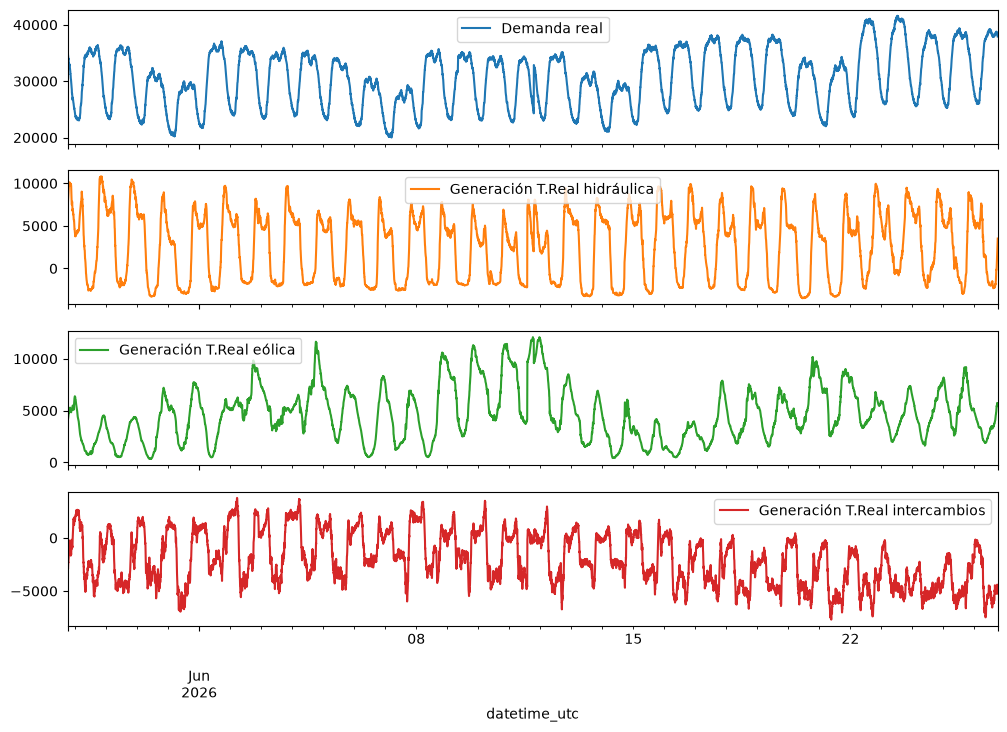

In [12]:
df_merged.plot(subplots=True, figsize=(12, 8))


¿De dónde viene esa frecuencia? ¿Del merge?
Investigar series 1293, 546, 551, 553

In [14]:
df_list[0]

,Demanda real,datetime,tz_time,geo_id,geo_name
datetime_utc,,,,,
2026-05-27 18:15:00+00:00,34773.0,2026-05-27T20:15:00.000+02:00,2026-05-27T18:15:00.000Z,8741,Península
2026-05-27 18:20:00+00:00,35007.0,2026-05-27T20:20:00.000+02:00,2026-05-27T18:20:00.000Z,8741,Península
2026-05-27 18:25:00+00:00,34770.0,2026-05-27T20:25:00.000+02:00,2026-05-27T18:25:00.000Z,8741,Península
2026-05-27 18:30:00+00:00,34426.0,2026-05-27T20:30:00.000+02:00,2026-05-27T18:30:00.000Z,8741,Península
2026-05-27 18:35:00+00:00,34240.0,2026-05-27T20:35:00.000+02:00,2026-05-27T18:35:00.000Z,8741,Península
...,...,...,...,...,...
2026-06-26 17:40:00+00:00,38176.0,2026-06-26T19:40:00.000+02:00,2026-06-26T17:40:00.000Z,8741,Península
2026-06-26 17:45:00+00:00,38132.0,2026-06-26T19:45:00.000+02:00,2026-06-26T17:45:00.000Z,8741,Península
2026-06-26 17:50:00+00:00,38108.0,2026-06-26T19:50:00.000+02:00,2026-06-26T17:50:00.000Z,8741,Península


In [15]:
df_list[1]

,Generación T.Real hidráulica,datetime,tz_time,geo_id,geo_name
datetime_utc,,,,,
2026-05-27 18:15:00+00:00,7044.0,2026-05-27T20:15:00.000+02:00,2026-05-27T18:15:00.000Z,8741,Península
2026-05-27 18:20:00+00:00,7266.0,2026-05-27T20:20:00.000+02:00,2026-05-27T18:20:00.000Z,8741,Península
2026-05-27 18:25:00+00:00,7847.0,2026-05-27T20:25:00.000+02:00,2026-05-27T18:25:00.000Z,8741,Península
2026-05-27 18:30:00+00:00,7986.0,2026-05-27T20:30:00.000+02:00,2026-05-27T18:30:00.000Z,8741,Península
2026-05-27 18:35:00+00:00,8227.0,2026-05-27T20:35:00.000+02:00,2026-05-27T18:35:00.000Z,8741,Península
...,...,...,...,...,...
2026-06-26 17:40:00+00:00,1787.0,2026-06-26T19:40:00.000+02:00,2026-06-26T17:40:00.000Z,8741,Península
2026-06-26 17:45:00+00:00,2410.0,2026-06-26T19:45:00.000+02:00,2026-06-26T17:45:00.000Z,8741,Península
2026-06-26 17:50:00+00:00,2864.0,2026-06-26T19:50:00.000+02:00,2026-06-26T17:50:00.000Z,8741,Península


In [16]:
df_list[2]

,Generación T.Real eólica,datetime,tz_time,geo_id,geo_name
datetime_utc,,,,,
2026-05-27 18:15:00+00:00,4080.0,2026-05-27T20:15:00.000+02:00,2026-05-27T18:15:00.000Z,8741,Península
2026-05-27 18:20:00+00:00,4111.0,2026-05-27T20:20:00.000+02:00,2026-05-27T18:20:00.000Z,8741,Península
2026-05-27 18:25:00+00:00,4120.0,2026-05-27T20:25:00.000+02:00,2026-05-27T18:25:00.000Z,8741,Península
2026-05-27 18:30:00+00:00,4196.0,2026-05-27T20:30:00.000+02:00,2026-05-27T18:30:00.000Z,8741,Península
2026-05-27 18:35:00+00:00,4267.0,2026-05-27T20:35:00.000+02:00,2026-05-27T18:35:00.000Z,8741,Península
...,...,...,...,...,...
2026-06-26 17:40:00+00:00,5739.0,2026-06-26T19:40:00.000+02:00,2026-06-26T17:40:00.000Z,8741,Península
2026-06-26 17:45:00+00:00,5679.0,2026-06-26T19:45:00.000+02:00,2026-06-26T17:45:00.000Z,8741,Península
2026-06-26 17:50:00+00:00,5697.0,2026-06-26T19:50:00.000+02:00,2026-06-26T17:50:00.000Z,8741,Península


In [17]:
df_list[3]

,Generación T.Real intercambios,datetime,tz_time,geo_id,geo_name
datetime_utc,,,,,
2026-05-27 18:15:00+00:00,-3042.0,2026-05-27T20:15:00.000+02:00,2026-05-27T18:15:00.000Z,8741,Península
2026-05-27 18:20:00+00:00,-2790.0,2026-05-27T20:20:00.000+02:00,2026-05-27T18:20:00.000Z,8741,Península
2026-05-27 18:25:00+00:00,-2880.0,2026-05-27T20:25:00.000+02:00,2026-05-27T18:25:00.000Z,8741,Península
2026-05-27 18:30:00+00:00,-2921.0,2026-05-27T20:30:00.000+02:00,2026-05-27T18:30:00.000Z,8741,Península
2026-05-27 18:35:00+00:00,-2531.0,2026-05-27T20:35:00.000+02:00,2026-05-27T18:35:00.000Z,8741,Península
...,...,...,...,...,...
2026-06-26 17:40:00+00:00,-4422.0,2026-06-26T19:40:00.000+02:00,2026-06-26T17:40:00.000Z,8741,Península
2026-06-26 17:45:00+00:00,-4798.0,2026-06-26T19:45:00.000+02:00,2026-06-26T17:45:00.000Z,8741,Península
2026-06-26 17:50:00+00:00,-4676.0,2026-06-26T19:50:00.000+02:00,2026-06-26T17:50:00.000Z,8741,Península
